# Day 12: Time Series Analysis & Autocorrelation

**Date:** May 23, 2026

**Index:** Nifty 50 (^NSEI) 

**Period:** January 2020 – January 2025  

## Overview

A time series is any data recorded sequentially over time where order matters.
In finance, stock prices and returns are classic time series. Before modelling
any time series, we must answer two questions:

1. **Is the series stationary?** — does its mean and variance stay constant over time?
2. **Is the series autocorrelated?** — do past values help predict future values?

This notebook tests both properties on Nifty 50 data using the Autocorrelation
Function (ACF) and the Augmented Dickey-Fuller (ADF) test.

In [3]:
# --- Imports ---
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

# --- Load Data ---
nifty = yf.download("^NSEI", start="2020-01-01", end="2025-01-01", auto_adjust=True)
price  = nifty["Close"].squeeze()
returns = price.pct_change().dropna()

print(f"Price series  : {len(price)} observations")
print(f"Returns series: {len(returns)} observations")
print(f"Date range    : {price.index[0].date()} to {price.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed

Price series  : 1237 observations
Returns series: 1236 observations
Date range    : 2020-01-01 to 2024-12-31


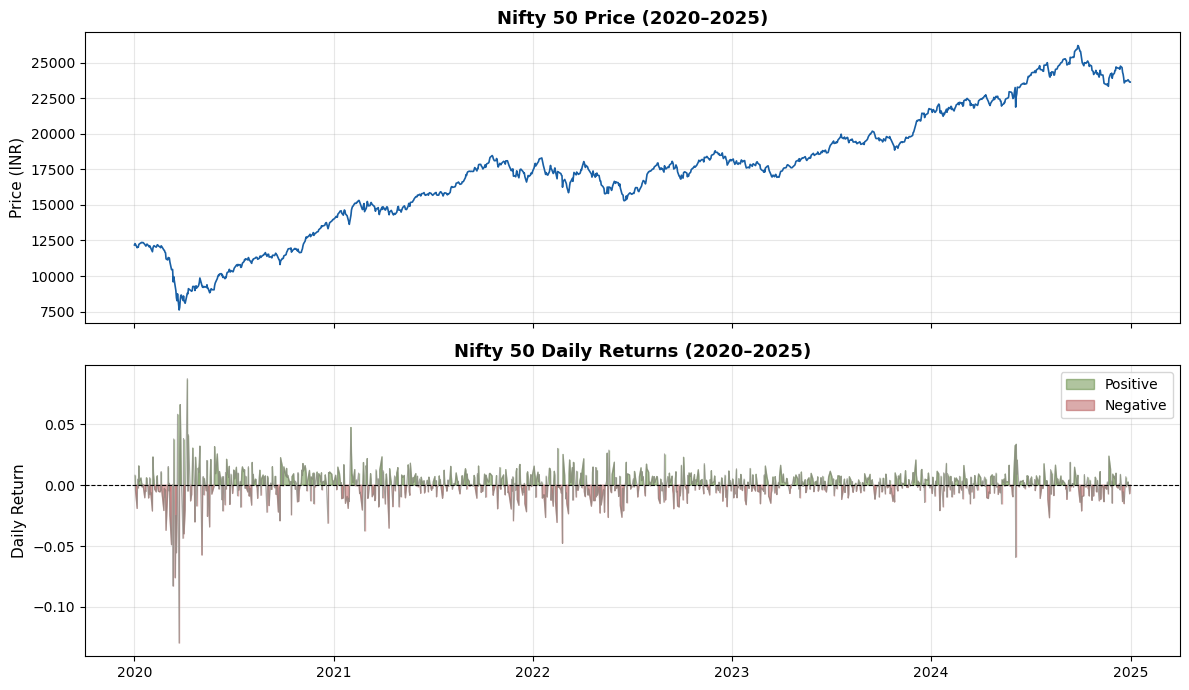

In [4]:
# --- Price vs Returns Plot ---

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top plot: Price series
ax1.plot(price, color="#185FA5", linewidth=1.2)
ax1.set_title("Nifty 50 Price (2020–2025)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Price (INR)", fontsize=11)
ax1.grid(True, alpha=0.3)

# Bottom plot: Returns series
ax2.plot(returns, color="#888780", linewidth=0.8, alpha=0.7)
ax2.fill_between(returns.index, returns, 0,
                 where=(returns >= 0), color="#3B6D11", alpha=0.4, label="Positive")
ax2.fill_between(returns.index, returns, 0,
                 where=(returns < 0),  color="#A32D2D", alpha=0.4, label="Negative")
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_title("Nifty 50 Daily Returns (2020–2025)", fontsize=13, fontweight="bold")
ax2.set_ylabel("Daily Return", fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation: Price vs Returns

The two panels illustrate the concept of stationarity clearly:

- **Price series (non-stationary):** The mean continuously drifts upward from ~7,500
  to ~26,000. Shocks (like the COVID crash) are absorbed into a new, higher level.
  This series cannot be used directly in time series models.

- **Returns series (stationary):** The series bounces around a constant mean near zero
  throughout the entire period. Shocks are temporary — the series always reverts back.
  This is the correct input for time series modelling.

- **Volatility clustering:** The 2020 period shows dramatically larger swings than
  2022–2024. Large moves tend to be followed by more large moves — a phenomenon
  modelled by GARCH (covered later in this programme).

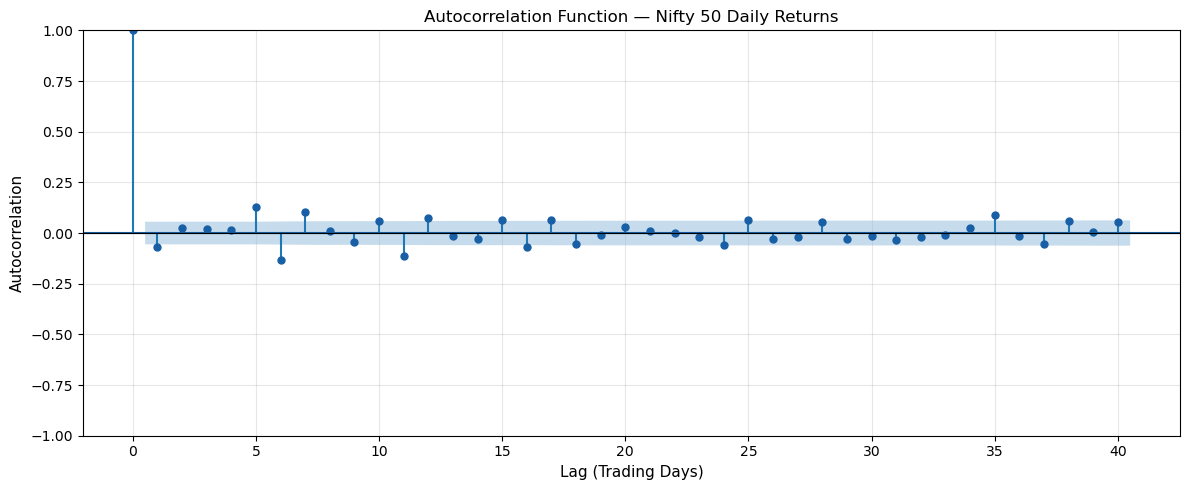

In [5]:
# --- ACF Plot ---

fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(returns, lags=40, ax=ax, color="#185FA5",
         title="Autocorrelation Function — Nifty 50 Daily Returns")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Lag (Trading Days)", fontsize=11)
ax.set_ylabel("Autocorrelation", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation: Autocorrelation Function (ACF)

The ACF plot tests whether past returns can predict future returns.

- **Lag 0** is always 1.0 by definition — a series is perfectly correlated with itself.
- **Lags 1–40** show autocorrelations clustered tightly around zero, with nearly all
  bars falling within the 95% confidence cone (blue shaded region).
- A handful of lags marginally touch the cone boundary — this is expected by chance
  alone when testing 40 lags simultaneously (roughly 2 out of 40 will cross at random).

**Conclusion:** Nifty 50 daily returns show no meaningful autocorrelation. Past returns
do not predict future returns at the daily frequency — consistent with the weak form
of the Efficient Market Hypothesis (EMH).

**Note:** Autocorrelation in raw returns is near-zero, but autocorrelation in *squared*
returns (a proxy for volatility) is significantly positive — meaning volatility clusters
over time. This is the foundation of GARCH modelling covered later in this programme.

In [6]:
# --- ADF Test ---

def run_adf(series, name):
    result = adfuller(series)
    adf_stat   = result[0]
    p_value    = result[1]
    crit_vals  = result[4]

    print(f"{'='*50}")
    print(f"ADF Test: {name}")
    print(f"{'='*50}")
    print(f"ADF Statistic : {adf_stat:.4f}")
    print(f"P-Value       : {p_value:.6f}")
    print()
    print("Critical Values:")
    for key, val in crit_vals.items():
        print(f"   {key} : {val:.4f}")
    print()

    if p_value < 0.05:
        print(f"Decision: STATIONARY ✓ (reject unit root)")
    else:
        print(f"Decision: NON-STATIONARY ✗ (fail to reject unit root)")
    print()

# Run on price series
run_adf(price, "Nifty 50 Price")

# Run on returns series
run_adf(returns, "Nifty 50 Daily Returns")

ADF Test: Nifty 50 Price
ADF Statistic : -0.4706
P-Value       : 0.897629

Critical Values:
   1% : -3.4357
   5% : -2.8639
   10% : -2.5680

Decision: NON-STATIONARY ✗ (fail to reject unit root)

ADF Test: Nifty 50 Daily Returns
ADF Statistic : -10.4801
P-Value       : 0.000000

Critical Values:
   1% : -3.4357
   5% : -2.8639
   10% : -2.5680

Decision: STATIONARY ✓ (reject unit root)



### ADF Test Results & Final Summary

| Series          | ADF Statistic | P-Value  | Decision          |
|-----------------|---------------|----------|-------------------|
| Nifty 50 Price  | -0.4706       | 0.8976   | Non-stationary ✗  |
| Nifty 50 Returns| -10.4801      | ~0.0000  | Stationary ✓      |

**Interpretation:**

1. **Price series (non-stationary):** The ADF statistic of −0.47 is far from the
   critical value of −2.86 at the 5% level. P-value of 0.897 means we cannot
   reject the unit root — the price series drifts permanently and cannot be
   modelled directly.

2. **Returns series (stationary):** The ADF statistic of −10.48 is far beyond
   even the 1% critical value of −3.43. P-value is essentially zero — returns
   are confirmed stationary with overwhelming confidence.

**Key takeaway:** Always test for stationarity before modelling any financial
time series. The standard transformation — taking percentage returns from prices
— is confirmed by the ADF test to produce a stationary series suitable for
ARIMA, VAR, and other time series models covered in the coming days.